# Regional Rent Growth and Housing Cost Analysis

This notebook examines regional differences in rent growth
across U.S. metropolitan areas using Zillow rental data.

The goal is to identify whether housing costs have increased
uniformly across the United States or whether certain regions
have experienced significantly higher rent growth during the
study period.

## Load Zillow Rent Dataset

The Zillow Observed Rent Index (ZORI) dataset contains monthly rent
estimates for metropolitan areas across the United States.

For this analysis, we focus on identifying regional trends in rent
growth over time.

In [138]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Zillow rent dataset
rent_df = pd.read_csv(
    "Dataset #3 - Metro_zori_uc_sfrcondomfr_sm_month.csv"
)

## Initial Data Inspection

Before performing any analysis, we examine the structure of the
dataset and identify the columns needed for regional analysis.

In [139]:
pd.DataFrame({
    "Dataset": ["Earnings", "Inflation", "Rent"],
    "Rows": [348, 15, 720],
    "Columns": [133, 133, 141]
})

,Dataset,Rows,Columns
0,Earnings,348,133
1,Inflation,15,133
2,Rent,720,141


In [140]:
rent_df[['RegionName','StateName','RegionType']].head(20)

,RegionName,StateName,RegionType
0,United States,NaN,country
1,"New York, NY",NY,msa
2,"Los Angeles, CA",CA,msa
3,"Chicago, IL",IL,msa
4,"Dallas, TX",TX,msa
5,"Houston, TX",TX,msa
6,"Washington, DC",VA,msa
7,"Philadelphia, PA",PA,msa
8,"Miami, FL",FL,msa
9,"Atlanta, GA",GA,msa


## Regional Classification

To compare housing affordability across the United States,
metropolitan areas are grouped into the four Census-style regions:

- Northeast
- Midwest
- South
- West

This classification allows regional rent growth trends to be
compared over time.

In [141]:
rent_df['RegionType'].value_counts()

RegionType
msa        719
country      1
Name: count, dtype: int64

In [142]:
# Check for missing values in key geographic columns
rent_df[['RegionName', 'StateName', 'RegionType']].isnull().sum()

RegionName    0
StateName     1
RegionType    0
dtype: int64

In [143]:
# Number of metropolitan areas represented
rent_df['RegionName'].nunique()

720

In [144]:
rent_df['StateName'].value_counts().head(20)

StateName
TX    48
NC    34
CA    32
PA    30
FL    27
OH    27
NY    25
GA    24
IN    24
TN    23
WI    23
MI    20
WA    19
OR    19
AL    19
MN    18
MO    18
IL    17
OK    17
CO    16
Name: count, dtype: int64

## Filter to Metropolitan Areas

The Zillow dataset contains one national observation ("United States")
and hundreds of metropolitan statistical areas (MSAs).

Because this analysis focuses on regional housing markets,
only metropolitan areas are retained.

In [145]:
# Keep only metropolitan statistical areas (MSAs)
metro_df = rent_df[rent_df['RegionType'] == 'msa'].copy()

metro_df.shape

(719, 141)

## Regional Classification

Metropolitan areas are grouped into four major U.S. regions
(Northeast, Midwest, South, and West) based on state location.

This allows regional housing trends to be compared over time.

In [146]:
region_dict = {

    # Northeast
    'CT':'Northeast',
    'ME':'Northeast',
    'MA':'Northeast',
    'NH':'Northeast',
    'RI':'Northeast',
    'VT':'Northeast',
    'NJ':'Northeast',
    'NY':'Northeast',
    'PA':'Northeast',

    # Midwest
    'IL':'Midwest',
    'IN':'Midwest',
    'MI':'Midwest',
    'OH':'Midwest',
    'WI':'Midwest',
    'IA':'Midwest',
    'KS':'Midwest',
    'MN':'Midwest',
    'MO':'Midwest',
    'NE':'Midwest',
    'ND':'Midwest',
    'SD':'Midwest',

    # South
    'DE':'South',
    'FL':'South',
    'GA':'South',
    'MD':'South',
    'NC':'South',
    'SC':'South',
    'VA':'South',
    'WV':'South',
    'AL':'South',
    'KY':'South',
    'MS':'South',
    'TN':'South',
    'AR':'South',
    'LA':'South',
    'OK':'South',
    'TX':'South',

    # West
    'AZ':'West',
    'CO':'West',
    'ID':'West',
    'MT':'West',
    'NV':'West',
    'NM':'West',
    'UT':'West',
    'WY':'West',
    'AK':'West',
    'CA':'West',
    'HI':'West',
    'OR':'West',
    'WA':'West'
}

In [147]:
metro_df['Region'] = metro_df['StateName'].map(region_dict)

In [148]:
region_summary = (
    metro_df['Region']
    .value_counts()
    .reset_index()
)

region_summary.columns = ['Region', 'Metro Count']

region_summary.sort_values(
    'Metro Count',
    ascending=False
)

,Region,Metro Count
0,South,276
1,Midwest,199
2,West,160
3,Northeast,84


In [149]:
metro_df[metro_df['Region'].isna()][['RegionName','StateName']]

,RegionName,StateName


## Regional Rent Growth

To compare housing market trends across the United States,
average rent values are calculated for each region and indexed
to January 2016 = 100.

Indexing allows regions with different absolute rent levels
to be compared on the same scale.

In [150]:
# Monthly rent observations begin after the geographic identifier columns
date_cols = metro_df.columns[5:-1]

# Calculate average rent by region for each month
regional_rent = (
    metro_df
    .groupby('Region')[date_cols]
    .mean()
)

regional_rent.head()

,2015-01-31,2015-02-28,2015-03-31,2015-04-30,2015-05-31,2015-06-30,2015-07-31,2015-08-31,2015-09-30,2015-10-31,...,2025-07-31,2025-08-31,2025-09-30,2025-10-31,2025-11-30,2025-12-31,2026-01-31,2026-02-28,2026-03-31,2026-04-30
Region,,,,,,,,,,,,,,,,,,,,,
Midwest,822.927712,828.002330,825.634215,829.552889,829.604710,833.258760,833.712531,835.898945,839.748365,840.087840,...,1175.530016,1177.043641,1180.603106,1182.843785,1184.679523,1182.425519,1176.060115,1175.649867,1171.860429,1164.765298
Northeast,1101.871505,1105.269035,1113.071394,1119.997325,1142.598928,1132.244984,1136.088973,1137.694727,1137.261639,1135.755476,...,1638.305003,1636.199618,1638.182874,1636.651569,1635.405169,1630.689472,1611.508934,1606.830334,1631.471384,1589.988884
South,951.217696,953.232781,958.899543,958.241397,963.839956,967.195654,972.461813,973.637736,974.582316,974.845284,...,1454.896377,1458.474304,1454.965136,1448.885752,1446.105726,1441.409787,1438.030428,1446.114541,1446.151359,1443.298944
West,1148.442669,1153.875751,1161.623018,1164.393885,1175.007963,1182.010271,1190.380040,1197.626172,1196.477988,1199.840325,...,1871.749288,1876.877968,1880.005360,1875.294730,1872.302883,1856.862845,1862.816082,1871.717799,1882.023371,1865.282239


In [151]:
# Use January 2016 as the baseline
base_month = '2016-01-31'

regional_index = regional_rent.div(
    regional_rent[base_month],
    axis=0
) * 100

# Keep only dates from January 2016 onward
regional_index = regional_index.loc[:, '2016-01-31':]

regional_index.head()

,2016-01-31,2016-02-29,2016-03-31,2016-04-30,2016-05-31,2016-06-30,2016-07-31,2016-08-31,2016-09-30,2016-10-31,...,2025-07-31,2025-08-31,2025-09-30,2025-10-31,2025-11-30,2025-12-31,2026-01-31,2026-02-28,2026-03-31,2026-04-30
Region,,,,,,,,,,,,,,,,,,,,,
Midwest,100.0,100.296780,101.220051,101.951198,100.528540,100.912657,101.274725,101.397322,101.391752,101.220304,...,139.138089,139.317244,139.738550,140.003761,140.221043,139.954254,139.200832,139.152274,138.703749,137.863955
Northeast,100.0,100.546530,101.155061,102.319640,99.979672,100.517765,100.661929,101.216577,101.096886,102.374511,...,145.624589,145.437447,145.613733,145.477619,145.366830,144.947664,143.242757,142.826889,145.017166,141.329897
South,100.0,100.160665,100.535430,100.639275,100.793034,101.175856,101.241697,101.351269,101.407259,101.356640,...,148.786478,149.152378,148.793509,148.171795,147.887493,147.407258,147.061664,147.888394,147.892160,147.600454
West,100.0,100.449491,101.221705,102.862957,103.688335,104.412995,105.045175,105.338023,105.499870,105.424166,...,156.858951,157.288752,157.550838,157.156071,156.905344,155.611417,156.110318,156.856312,157.719954,156.316990


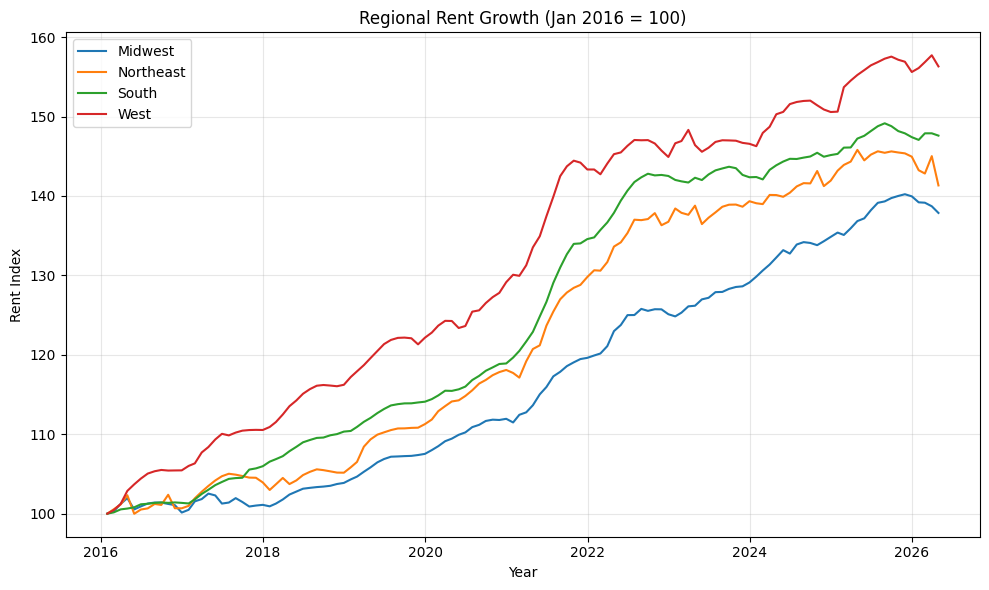

In [152]:
plt.figure(figsize=(10,6))

for region in regional_index.index:
    plt.plot(
        pd.to_datetime(regional_index.columns),
        regional_index.loc[region],
        label=region
    )

plt.title('Regional Rent Growth (Jan 2016 = 100)')
plt.xlabel('Year')
plt.ylabel('Rent Index')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Regional Growth Summary

To quantify differences in housing market growth,
the percentage increase in average rent from January 2016
to April 2026 is calculated for each region.

In [153]:
growth_summary = pd.DataFrame({
    'Region': regional_index.index,
    'Rent Growth (%)':
        regional_index['2026-04-30'] - 100
})

growth_summary = growth_summary.sort_values(
    'Rent Growth (%)',
    ascending=False
)

print("\nRegional Rent Growth from Jan 2016 to Apr 2026")

growth_summary.round(2)


Regional Rent Growth from Jan 2016 to Apr 2026


,Region,Rent Growth (%)
Region,,
West,West,56.32
South,South,47.60
Northeast,Northeast,41.33
Midwest,Midwest,37.86


## Interpretation

Regional rent growth was not uniform across the United States.

The West experienced the largest increase in rent levels between
2016 and 2026, reaching an index value of approximately 156.
The South also experienced substantial growth, particularly during
the 2021–2022 period.

Average rent growth between 2016 and 2026 ranged from
approximately 38% in the Midwest to more than 56% in the West,
highlighting substantial regional variation in housing cost increases.

The Midwest exhibited the slowest rent growth over the study period,
while the Northeast fell between the Midwest and the faster-growing
South and West regions.

These findings suggest that regional housing markets responded
differently to economic conditions over the past decade.

In [ ]:
regional_index.to_csv('regional_index.csv', index=True)